-# Algorithmes : Arbres de recherche
Pour tester les différents programmes dans la suite, on utilisera deux manières d'implémenter un arbre.
* soit sous la forme d'une liste. Par exemple :
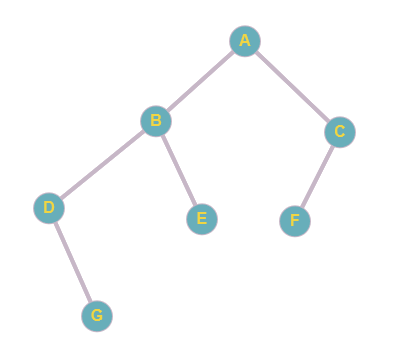
On écrit cet arbre sous la forme :

In [ ]:
arbre = ['A',['B',['D',[],['G',[], []]], ['E',[],[]]],['C', ['F', [], []], []]]

In [ ]:
arbre

['A', ['B', ['D', [], ['G', [], []]], ['E', [], []]], ['C', ['F', [], []], []]]

* Autre forme avec la classe ```Arbre``` :

In [ ]:
class Arbre:
    def __init__(self, val):
        self.valeur = val
        self.gauche = None
        self.droit = None

    def ajout_gauche(self, val):
        self.gauche = Arbre(val)

    def ajout_droit(self, val):
        self.droit = Arbre(val)

b = Arbre('A')
b.ajout_gauche('B')
b.ajout_droit('C')
b.gauche.ajout_gauche('D')
b.gauche.ajout_droit('E')
b.gauche.gauche.ajout_droit('G')
b.droit.ajout_gauche('F')

**Exercice n°1**
Ecrire cet arbre sous les 2 formes décrites précédemment :
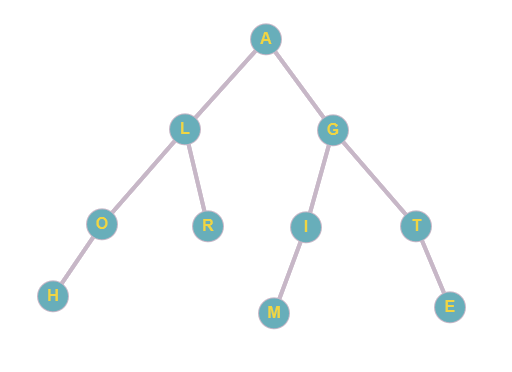

In [ ]:
arbre2 = ["A", ["L", ["O", ["H", [], []], []], ["R",[], []]], \
         ["G", ["I", ["M", [], []], [], []], ["T", ["E", [], []], [], []]]]

c = Arbre("A")
c.ajout_gauche("L")
c.gauche.ajout_gauche("O")
c.gauche.gauche.ajout_gauche("H")
c.gauche.ajout_droit("R")
c.ajout_droit("G")
c.droit.ajout_gauche("I")
c.droit.gauche.ajout_gauche("M")
c.droit.ajout_droit("T")
c.droit.droit.ajout_droit("E")

## Taille et hauteur d'un arbre binaire
### Taille d'un arbre binaire
Il s'agit de déterminer le nombre total de noeuds.  
**Principe de l'algorithme** :
* si l'arbre est vide, il y a 0 noeud;
* sinon, calculer la somme du noeud racine, du nombre des noeuds du sous-arbre gauche et du nombre des noeuds du sous-arbre droit.  

<ol>
<li> Ecrire une 1ère implémentation en Python pour un arbre sous forme de liste :</li>

In [ ]:
def taille1(arb):
      if arb == []:
        return 0
      return 1 + taille1(arb[1]) + taille1(arb[2])

arbre = ['A',['B',['D',[],['G',[], []]], ['E',[],[]]],['C', ['F', [], []], []]]
print(taille1(arbre))

arbre2 = ["A", ["L", ["O", ["H", [], []], []], ["R",[], []]], \
         ["G", ["I", ["M", [], []], [], []], ["T", ["E", [], []], [], []]]]
print(taille1(arbre2))

7
10


<ol>
<li>Deuxième implémentation avec la classe ```Arbre``` :</li>

In [ ]:
class Arbre:
    def __init__(self, val):
        self.valeur = val
        self.gauche = None
        self.droit = None

    def ajout_gauche(self, val):
        self.gauche = Arbre(val)

    def ajout_droit(self, val):
        self.droit = Arbre(val)

def taille2(arb):
    if arb is None:
      return 0
    return 1 + taille2(arb.gauche) + taille2(arb.droit)

c = Arbre("A")
c.ajout_gauche("L")
c.gauche.ajout_gauche("O")
c.gauche.gauche.ajout_gauche("H")
c.gauche.ajout_droit("R")
c.ajout_droit("G")
c.droit.ajout_gauche("I")
c.droit.gauche.ajout_gauche("M")
c.droit.ajout_droit("T")
c.droit.droit.ajout_droit("E")

taille2(c)

10

Tester vos deux implémentations avec les deux arbres précédents.

### Hauteur d'un arbre binaire
Il s'agit de déterminer le nombre maximal de noeuds se trouvant entre la racine et une feuille.  
**Principe de l'algorithme** :
* si l'arbre est vide, la hauteur est nulle;
* sinon, calculer la somme du noeud racine et de la plus grande hauteur du sous-arbre gauche et du sous-arbre droit.  


1. Ecrire cette fonction en Python, utilisable avec les deux implémentations :

In [ ]:
def hauteur(arb):
    if arb == []:
      return 0
    return 1 + max(hauteur(arb[1]), hauteur(arb[2]))

arbre = ['A',['B',['D',[],['G',[], []]], ['E',[],[]]],['C', ['F', [], []], []]]
hauteur(arbre)

4

In [ ]:
class Arbre:
    def __init__(self, val):
        self.valeur = val
        self.gauche = None
        self.droit = None

    def ajout_gauche(self, val):
        self.gauche = Arbre(val)

    def ajout_droit(self, val):
        self.droit = Arbre(val)

def hauteur(arb):
  if arb is None:
    return 0
  return 1 + max(hauteur(arb.gauche), hauteur(arb.droit))

c = Arbre("A")
c.ajout_gauche("L")
c.gauche.ajout_gauche("O")
c.gauche.gauche.ajout_gauche("H")
c.gauche.ajout_droit("R")
c.ajout_droit("G")
c.droit.ajout_gauche("I")
c.droit.gauche.ajout_gauche("M")
c.droit.ajout_droit("T")
c.droit.droit.ajout_droit("E")
hauteur(c)

4

Tester avec les deux implémentations (liste et classe) des deux arbres précédents.

## Parcours d'un arbre binaire
On parcourt un arbre pour calculer sa taille ou sa hauteur, pour chercher une valeur particulière ou pour afficher les différents valeurs... Il existe de différentes façons d'effectuer ce parcours : le parcours en profondeur d'abord et le parcours en largeur d'abord.  
### Parcours en profondeur d'abord
En anglais, on parle de Depth-First Search (DFS).  
**Principe** : on explore chaque branche complètement avant d'explorer la branche voisine.  
La programmation récursive est indiquée :
* si l'arbre est non vide, on parcourt de manière récursive son sous-arbre gauche puis sous-arbre droit;
* sinon, c'est terminé.

On distingue 3 cas suivant le moment où est traitée une racine d'un sous-arbre. Traiter une racine signifie par exemple afficher la valeur.

* Si la racine est avant ses deux sous-arbres, il s'agit d'un ordre **préfixe**.
* Si la racine est entre ses deux sous-arbres, il s'agit d'un ordre **infixe**.
* Si la racine est après ses deux sous-arbres, il s'agit d'un ordre **postfixe**.

#### Parcours préfixe
![parcours_prefixe.png](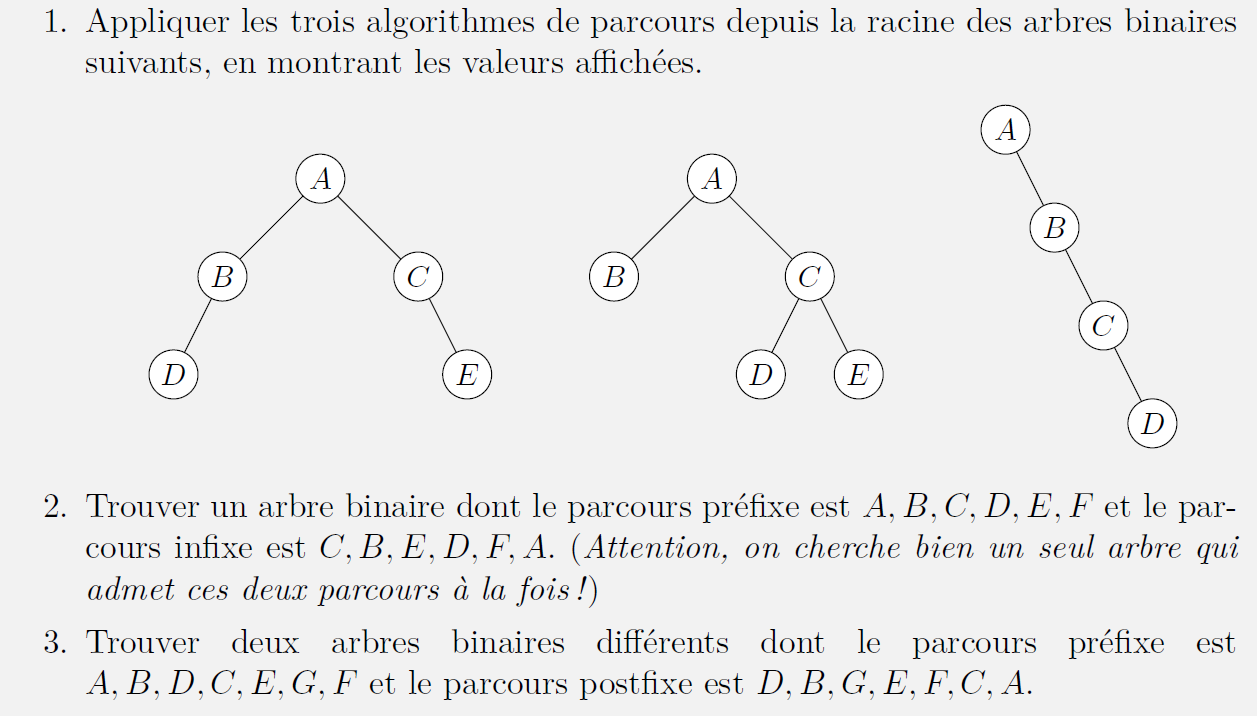+WZXDgvFU0sIyQ6KPkJyCD8LMnShFwVv0P79++XRRx+VCRMmqHfqOfXUU2Xo0KFa2LZDhw6m+XvI89u6dasWBjb7M8DChQtl8ODB6ikaBCX8dJre+VCoHlxCiDMo+gjJAfwK30ZJ6Ol8/vnnctNNNx3k3YOHDnl6Z5zhrB0MBOTq1avlqaeeMv0z77///kjl+wUt/AD2QcHlQ6Vp7z5s8UJIhKHoIySh+BW+jaLQ04Hgg/fNWKABoYcQb/fu2XujFi1aJA899FCDP3/48OHy+OOPR0b4oRhn7+hbfCvEsSLvpzdIwQU/Zq9FQiIIRR8hCcKv6ts4JPKbCT4UX1x77bWeCjJUAI8dO7ZBUUhihF9+7ddfsV89ZIe+ZwoGXkDvHyERgaKPkATgh1cvClW3doEQGzBgQAPBt3z5cq3a1g8Q8p0zZ46MGjVKvVMn/H7zm9+op/BxI/yaPzJPGn/nO56nArD4g5BoQNFHSEzxy6un99GLU3juuuuua+B5e+uttxzn7rnhiSeeaCD85s6dqxWJRAWnws84dk1vzl06+9eeFf3oFwlOXSEkHCj6CIkZfnj19MkYTc/oHTtPDPLshgwZop6CF16pgnPz5s2R6uVnV/hhDxzy5Cz11BC/9hy9f4QEC0UfITEBFbhlr/xJKn//lHonO/SCjDjnXCGse8QRR6inumraqVOnqqdgQKi3T58+B0LLKBzBtI8oAa/dniHnZxRsLeYvs/Tu6t5lL/chvX+EBAdFHyERRu+rV/rYFM88LEkarWUMr6L/3rJly0JpmoyJH2eeeaZ6Ci687AR46/ZeeUnafdRq478dedywN8uWviLlLy/2LPxL7x8h/kLRR0gEqfy/LVL2+p8967cGr16z4T+PZfg2HalevrCbJY8ZM0amTZumraPo7QPphB8uAkVj7lJPzqn4YIOULV/qWfEHvX+E+ANFHyERAiFcrwozkn5wGnP54OV78803Q22ZgikenTp1Uk8i27dvN532ETZmws9OaNcOCP+Wv73a0+IP9v0jxDsaq/8SQkICB2XpksWy+6cXy74rB2Qt+BAiwyF+6KsrpcX1NybWU7J06VK1Eq1wI+weeSjegIdP54033lCraIH90HL+H7VLAcB/vRJU8CIX9Osvh/5+sbRctk4b05YtyB3E52LX2afJ/t/N08LKhBB30NNHSEjg8Nr/4gueVETmWjgsNbQblYrZefPmybBhw7R1VEO8OvD47TmriybMcDnwCz+8f0nKSyUkSCj6CAkY5OuVLl7oSf5TEnP17GAsnEBod82aNdraHaWy5Zmh0una9TJ04UqZO7idet85qSHekpKSyEzpMAPpBI1bHyl5/xGMYNZzVb1q/aLP/C3oP4CFH4TYgOFdQgICB+zeCWNl74BTshZ88HQgfIYwGsJpuXbgffHFF2ol0rdvX7VyQfVOWTf3Phl57QL1RnakehuR1xdlENYNSvAB/F3wKiL1oPDphZpoywZ4DvffPlR2dfuO7Jv5pOa9JISkh6KPEJ+B2NPz9bLpbYYQLsZkYWoCKi2DPKyjxscff6xWIqeddppaOaFY1k0/Wxo1aSs9r54qq9S7XoBxbDpbt25VK2LEj9w/VLojXL3nxhHaZ44QcjAUfYT4gF6cgeRziL1scpn0woxWK9+VZoMu5vD6Wnbt2qVWbimSU0avFGS31NRsk4VDj1fvZ89hhx2mVrXSsrhYrUg6dO8f+gR64f1DIZRe+IHPIAs/CKmHoo8QDzlQiXv+2VrYKZu8JXg/4AXBaCy2qyBJx2vvHz57+AzuPrWDFvpFPiEhuQ5FHyEeAG8CDpZsxR5CuM0eeFIL4cL7kcshXJK7HMj9q/0cIKUhW+8fQr/IpUWaBUK/uJwRkotQ9BGSBQfE3qkdtIPFrdjDoYbQFhLcm/9sKEO4hNSCzwFSGuD9K1q0WmvUnA1Is0DoF5czhn5JLkLRR4gLUsWeWw40Us7RKly3tGrVSq2ilzf37bffqpXIUUcdpVYkW9CTr+WkKZr3D95wvbm0Gxj6JbkKRR8hDvBK7MFjwXw993Tu3FmtRDZu3KhW0WD27NlqJXLkkUeqFfEKeP/gDdcmztRemHBxygY99MuqX5ILUPQRYgOvxB6S0+GpgMeC+XruOe6449RKZNq0aWoVPhs2bFCrOtq1c9/omWQGXnFcmHBx8qLwQ6/6Rd4fQr/M+yNJhKKPkAx4Ifa02aZK7CE5nfl62WOcegFSxVZYfPjhh2pV168vytM4koSXhR+pDZ+Z90eSBMewEWICDD3m4mbj1dMqcW8dyxFRPnHdddcdCKXOmDFDbrrpJm0dJr169ZL33ntPW8+dO1eGDh2qrUnwIFRb9sqfsmqIroN0jOZXX0vvPIk9FH2EGEBIp2TuMxR7MWDFihVy3nnnqSeRr7/+Wg4P0YtqnAcMwv56SB0YzVb68pKsPtM68CA2v2U083BJbKHoI6QWiL2yFcuk9LEpWbVd4fD3YIDAuuWWW6SkpEQ2bdqkvRe2t++iiy6SJUuWaOt+/frJySefrIV4U+fxknDw4jOuw4sdiSsUfSSn8Urs8fYfDBB7KNzQxRXCqWvWrNHWYPPmzaGIrEWLFsmQIUPUU0PuvPNOir+IgdBv6fy5WvFGNkD85V92lTT/yeXM1SWxgKKP5Cww/Pt/Nd31XFyKveBIFXtGTjzxRPnb3/6mrSGuHn/88UALKD7//PMGVbqDBg0y/Top/qIH+vOVvf5nT0K/+SPHS7OLhzDvj0Qaij6Sc1R8sEFKfnk/xV4MyCT2dBG1devWBrl9QYZ59+/fL5dffnmDrw+5fAg5W33dFH/RAYVbZUtfkbLZT2Ud+kXRR8EFP6Z9IJGEoo/kDLjV7392jutqPoRymk94QJucQfzFjtgziqbJkyfLhAkT1FMwwg+C7+abb27QjHn58uXSv3/9/nD67yDhgnSPig3rs4oA6PBySKIIRR9JPLjFl8x+WiqenqzecQaTtoPDrUgyE2B+Cr9vavfU2LFjbf99FH/xAxGB0hdfyLrlC+0HiRIUfSSx4NZeumiBlN57o3rHGTTWweGFKIIQGzBgwIE+eQD/vylTpnjaOgWNoEeMGHHQ3/Ob3/xGPaWH4i9+eNXyBfakYPgNUjDwAhZ9kNCg6COJBGOU3FbkUuwFh9ciCEUV8LYZ/7xTTz1Vxo0bJwMHDsyqwAOicubMmQ3CyGDSpEly2223OfqzKf7ih5d5f5jQw4pfEgYUfSRRZFukQWMcDH6KHoR677vvPu3PN6KLv759+zry/EFIvvTSSzJq1Cj1Tj3ZTt2g+IsfiCCUv71aSmf/Ouu8P076IEFD0UcSAUIwJU/NcJ1/Q7EXDEGKnEy98/D39O7dW44//ng58sgjpbCwUI4++mjZsmWL9uuoCMb6tddeM/1aISBnzZol3bt3V+9kB8VfPPGq3x/FHwkKij4Sa3DrzmZsGo1tMIQlahCSff755029dG7wKlScDoq/eJJtZwAdVvwSv6HoI7Elm7w9GNcWD06h2POZqIgYXfzNmzevQQGGXdBwGWFcv8ReKhR/8QR5f/tffCHrog+KP+IXFH0kduBWve+esa7yaVCkUTj5YRpTn4myaEHYduPGjfLuu+9qa7OvEV/fscceKz179pSuXbtqod8woPiLJ14VfUD8cZ438RKKPhIbsum3x4rcYKBI8Qd+X+OJF7O9Ae0X8QqKPhJ5dMO5/3Z3VZIs0vAfipJg4Pc5vmQ76xtQ/JFsoegjkSabUC6LNPyHIiQc+H2PL15U/EL8sdEzcQNFH4kk2YRykQdTeNd9kn+SN+00yMFQdEQD/hzii1cVv4xkECdQ9JHI4bYql6EP/6HIiCb8ucQXiL/SxQtdzwbXofgjdqDoI5EBxq/ksemuwh75I8dL4fCRNHg+QVERD/hzii9etXuh+COZoOgjoZNNg+UmAy6XwltHM2/PJygi4gl/bvGF4o/4CUUfCRXMyt136/WuQrnNJzwgBf36q3eIl1A0JAP+HOMLxF/56jezbvdC8UeMUPSRUIBB2/fwFFdJzDBihcOuYd6eD1AkJBP+XOOLV73+KP4IoOgjgeO2UIOhXP+gKMgN+HOOLxR/xAso+khgVP3zc9k3+QHHhRoM5foHRUBuwp97fKH4I9lA0UcCAd49NxM1WJXrDzz0CeA+iC8QfxUb1mc95YPiL7eg6CO+4naiBhost3hwCkO5HsNDnqSyv1Y8LF26VB566CF577331Lv1cF9EHy9GvFH85QYUfcQXcAstXbRASu+9Ub1jn+aPzGODZY/JJPZwoONg56Ge21D8xR+KP2IFRR/xHLfePRRqtBh/rzT53tHqHZItmcTeoEGDtIP8jDPOUO8QYi3+ZsyYIVdccYUcTlEQWSj+SDoo+ohnuPXusVDDezZs2CATJ06k2COuofiLPxR/JBWKPuIJbr17eT+9QVrcMZYGxSO2bNkis2fP1rx7qVDsETdQ/MWfbMUf55onB4o+kjVuKnNhRAonPyxN/5MCxAso9ojfUPzFH4o/QtFHXOO27x7asLQYdSuNhgdQ7JGgofiLPxR/uQtFH3GFW+9ei8dmSv5J3dU7xC0UeyRsKP7ijxfij/nY8YKijzjC7cxceve8gWKPRA2Kv/gD8Vcy/g7XEz7QV7X5LaOZrhMDKPqIbcpeWyH7J93ryDDQu+cNFHsk6lD8xRsvxrtR/EUfij5iCYzBvhmPScXTk9U79qB3L3so9kjcoPiLN16IP3RlaH71tZyoFEEo+khG0IqleMRQevcChmKPxB2Kv3hD8ZdMKPpIWvb/bp7jRsv07mUHxR5JGhR/8cYL8ccGz9GBoo8chJtWLKziyg6KPZJ0KP7iDYr49r/4gpRPG6fecQ7FX/hQ9JEGuKni4lQN91DskVyD4i/eZCv+4CBgj7/woOgjGm6LNZo/Mk+aDbpYPRG7UOyRXIfiL95A/JXMftrxmaHD6FA4UPQRLZxbfMcoRw06mwy4XFqMv1eafO9o9Q6xA8UeIQ2h+Is3KPbb/+wcx71bddjmJVgo+nIc9N4rGTlEPdmj2QNPSrPBl9I17wCKvTpvctXn29VTPVWfbZWaffvUkzlVO3dI9fZt6ilc8nudplb2aNSihTTpcIx6OhhWNtZB8RdvshV/rPQNBoq+HMVNOJetWJyTZLEHIw+qv/pSqv/9b21dufljqdm9S1tXf7LF9XinXAee9EatDlNPIo3btZcmbdqqp9oDsusJapU80UjxF2+yHe3GHHF/oejLQdyEc/FBLLp7Ir17NkmC2EPOTvXXX0nlR/8rNcV76/6761tHVd0kOHApa3J6H20NUdioqKU0/s53pHHrI6XxEa1jd4hS/MWbbEe7odK3cNg1PHM8hqIvx3ATzi18eiGTbW0SV7EHrx3CrJV//z8tjOo2REOiDfKnGh/f8YAoxH+jLggp/uJLtj3+9EpfFgt6B0VfjuAmnIsDoujhGSzWsEGcxB48eJWbN0nVp59IxTtv0XNHNODNRxg57/v/oeUgRi1sTPEXX3D+lC5a4LjZvw7OosK77mNqkQdQ9OUAbsK5dK3bIy5ir+KDDVK58UMpf3kx8+yIbZBbmH/6mdLkuOMlr1OXSHgEKf7iS7Y9/nAxKbxhFB0RWUDRl3Cc5lXAnV44+WGWz1sQB7EHoYeff8UfnnOdV0OIEXhc8vr20zwu+d17hHoppPiLL3BElDw1w3UaCZ0S7qHoSyhwp5fMfcbRjYq996yJutiDMS19eUmihR5u+0HA6mNrYDOa9h8o+T1PDc1uUPzFF+QSlzw23VWKCZs7u4OiL4HAhV58zzhHHyTenDITdbEHj17p/LmRyM8zVpGC1L52TY45VhoVFqqnOvCcxMuG3tbGDLP+hHqVtE6cqqXhBWx64cVSMPCCUMLAFH/xJZs2L7h4FN46mv39bELRlzBwyBSPGMpwrkfEQexl0xPLKXr/uNSWIIBG13/0Njra2qQ/YlREIvZJsyuHhRICpviLJ9lW+uaPHC8tRt1Kx4UFFH0JonTJYtl/+1D1ZA3DuenJdbGHEKrWzuOo72qVnHHs85br6F5G3XNYsebdwEWh3nKjae8+ge8fir944iY1SYchX2so+hKAm3YsDOeaE4ecvWwSoM3QBV6UKjSJvxgbb+sj7vzuzQib0/wnl4ci/hYsWCDDhg1T7zSE4i+aZGPr6NBID0VfzMEHY9/kBxzd3oNstgwR9eWXX8oXX3yhPb/77rvSqlUr6dy5s/Z83HHHSevWreXoo8P9cEZd7AGnntx0wCCiDQdy7RiSJUZgT6q2fab1cIQg9EMIhjW7+5taofv888/LqFGj1DsNiYr4gy3aunWrFBcXa6+NGzceZDPbt2+fMyIVXQhKfnm/q6gG58QfDEVfjHGTv9dy/h99v/28/fbb8uabb8qECRPUO9aceuqpMnToUOnfv7907BicEMkk9vA1jRs3TgYPHqzeCQc3hTmpIN+lae+z6MkjjoGdgQBEeNgrERhmGM5K/M2dO1cuvfRSaR6QUIAncv369Y5tJi6j/fr1C9xmhkE2+X5s7NwQir6Y4nScGkJ4fs7OtcqfcUIQnjU7Ym/gwIGBGf504Ja779brXSU2h5lMT5KLl42+YZfCGq6fSfwFYQPiZjOjAC7AJbOfdpTKpMNCjzoo+mKGmyRXuLib/yz7sGA64Nm77bbb0houGCTcRLt16yZFRUXaezt27JBt27bJqlWrMv7/pk6d6uktFoZ+5syZpjfqKIk9gGKNfVcOUE/2Qe5UswsHMZ+F+A7CweWr3shKAIbdQSAM8bdixQq5++67PbeZw4cPl/vuuy/0dBm/gfd53z1jHe857LUWj83Maa8fRV+MgODbO/oW22E+v40pbqqPPvqoqYDCrROGq0uXLpa5J59//rl89NFH8tRTT8mSJUvUu/Ug3ILQbzaEfat3ihvBF1aiPCEAAjCbxuDYvy2udzeb1QuCsBGwmRBlZhGGSZMmSZ8+faRHjx6Wf4eVzVy4cGHoaSlBgDxnNyHfXPb6UfTFBBjUvVdeYntzI4+h6OEZvnl7YHRuuummgwxOtsnQ6cKuEJH333+/Y4MbN7EHnAo+GLDC4SMp9kgkwOW0/O3VUjr71449MUhJaDn9V6Eexn7ZjKBtJkQkIjBRsm1+gJDvvoenOM43zVmvH0QfiTZl77xV823fH9Z8c1yRrdee8WNqqktK1P/be7Zv315Ta/xwWTjwGjRoUM3mzZvV78iet95666C/Y/jw4TUlNv9dX3/9dU2tMW3w/9df+HNrb8K2/6wgqdiy2fRnavbCnsDvJySqwHbtuuwi0/2b7rX7hut8tV928dKGmNlM2DMvbeby5cuzsplxp3zD+473Gl57p0yOxH4LCoq+iLP/pUWmGzXdq2T+XPX/9AcYwlTDAsPoh2HB3wWjZfy7rIxYXMUegOGxK+5zzVCReAM75uTiGhXhB7K1KWaCL2ibmStgz+AMNNtTmV4Qi7lygaboiyjYvMW/fsJ0g5q9YFBxq/YTGKlUgwLj5Sd2/844iz0deGjNfrapLxyghMSNqtrPqN09jhd+b5RwY2OibDOTDAScG6+f306TKMCcvgjipmAjiP578+bNa9DVvtaQaDkqfoPk55tvvlnLW9F5//33pXv37rHM2TMDbTCKB/dWT+lpMX8Z5ySTWOOk3ZTfnQfc4MTmPPHEEw1+XxRsZi7hpqE98kqLHnwosTnSFH0RAwUbxXeMsp0AHVTiM5KFO3XqpJ7qCivQTiUoYMQuv/zyA0nQMK54vv3227VnI3ESezq7f3qx5c+cgo8kBSeFaS2XrYvk5Bgr8Xf99dfLtddeq96pK6wYP368evIf2ExUA+vtXfA1oQF00gs7UsFeczq1Kuw2Qn5C0RchnE7YCLLFwZgxYw5Uh4VlPFKF5/nnny+vvvqqeoqn2AN2qnXDbmdBiNfYPYzRieCQ3z4f2fYa6cRfr169ZM2aNdo6KjZzYY60cjHDjdcPdjdpM+op+iKC0zYdQc7P3bBhg5x88snqSeStt94KrfN7argExFXs6Vh5+eDNPeTJWeqJkORgN5Wl+SPzpNmgi9VTNDGKP/Qn3bRpk/qVcEOrRpuZq94+HaeRNJC0cG9j9V8SIriB2BV8Wm+h+csCnVkJQ6aDhsthjvoxhksAQiYwYri9xtGQwbtrGdYdf69aEZIs4EHB/oZdywQ8NOjHFmXQZw/5el9//bXm5dNBKkyYuXToAaiDUO/q1avVU+6BvHd4jZErahdcSPYMOV/Lu04CFH0hs2/mk7ZdznrBRpB5Bri9Gpt+woCFCYQdkqF1ED6J86217PU/q5U5CC9wnBpJMtjfRbPmqaf0lC19Ra2iD6YI6eCiHCYQo0abiSkeuQwuGigOKlq02vKyoYOUKxTawUETdyj6QgJhjT03jrA9Qxcu5kNfXRm4AFi7dq1a1YUGojDQ+6KLLlIr0Qo70Ok+rmBkVSYwVo2QpINCDSvvS9nspzS7GXWiaDP796+PDMXdZnoFJnHgTM376Q3qHWvgoCme+stY7MN0UPSFgNOWLBizFdZoIqMBy3b+rVdgmLjx9qwnS8cN5JdkKtqBMeJoNZIrNBt8aUbPCz4rFRvWq6fo8tpr9ekaUbGZHTt21ASoDub2kjqvX8tJU7ScUbtUPD1ZO7+jnm6QDoq+gMFBv/v8s20LPoT3isbcFVr10EsvvaRW0qCYwxnVUrxluUwfdqI0atSo7tV2mEz/8xYpVr/DKf369VMrkY8//lit4kXlpsyGt+nZ56oVIckHNq7ZrWPVkznlq/+iVtHFmA5z5plnqpVT9siWN56RsWe3PWAz2w6bLovW7ay1pu4wClBU9ZJ6UCSE1kB2w716nh/O87hB0Rcg2CB2e1MBFGyE3aZD7/EEOnTooFbOqP7nS3JL3wFy5597yZxNu6WmZrds+kWePNJ/iNyy6DNXRgw3V51//OMfahUvKv/+f2plTn6PnmpFSG5Q0D9zQRu8LFEGOdBG2rdvr1ZOqL0kr5sjI8+9Vp5rP0H+uqNMavb+TX4hc2VIz+vkkXW71O9zRtu2bdVKZNu2bWpFdJBi4CTci3N8z1ldtM4bcYKiLyCwMewKPtw2otCIN/U2iLCqc0rl78t/L8/sFDn+9htkaOdDat87RDpf8jO5qs1Geebp1+XvLlTfMccco1bSoOt8nKjent7wYg8wtEtyDXj7kM6SCVS8R5WvvvpKrepAEYVzvpE1L/5OVskpctWwy6RXm6YiRV3lkmEXShv5H3nkxfWyR/1OJ3Tr1k2tGnojST16uNdJdS86b2DKTFyg6AsAvQefXcEXdIWuv1TK3m++rP3v8XLGcd+RvLo361mxRjZ+Uakecouqd95Uq4NpcnoftSIkt2ja+yy1Mqfqs61qlVSaytHn3SMLFz4gP+mCSzIJGlT3wvFiN9yLsYLoxBEHKPp8xkkPPm2kWgAzdIOlSE4ZvVJqav4ucwe3U+/tknWzHpGpO2uX/XtJt6MOkoI5QaZLQKNDW6kVIblFXqcuamVO9Rf/Uqto47691SHS8ZxBMnjw+XIKvHxaTvRLMunBZ2Wn/Jfc/pMetb+D+A0cLziPMRHGDujEEQfhR9HnI0568OkzdBPfk616p6x59Ba58M7/qX3oJteMPFe+z114EHmdOqsVIbmFVVpD5Uf2cqLDxpsQ6nZZNKyjtOw0RKauEuk75hr5cSdKvqDAeYxmzjif7QDht3fC2Ei3dOFx6xMQfHZ78IXZkiU4cFtdJGPPPUV+ePu82htrG+l71yPyi4s6cBMSQhpg95BNPu1k8Ny/S03VDvnrIz+SzVOHSN9bXpJ/ui3hJY7BuYwxmOikYYfK3z+ltXSJqvDjeesx+EGjeaNdwRd2S5ZMtGunh2PrcN/Qs1x2vvGgXKjdVrWYroxZ+Ia8PPlH0sblDty6tT6vZ/jw4WpFCEkCjVodplbxonXr1mpVR2o1ry0q18n076NNy/WyaKfKd27cRnqNulluP15k5zMr5K8u8qA3btyoVuFPVooj6KRht58fWrpEVfhR9HmI3nTZblsBbKCwW7JkAuPNjA09P/vsM7VyRvU/X5G7r5woq2rXbYY+IX/d8bJMGdxZiup+2RXGyuJjjz1WrQghJDxSq3VdtUbJ6yA9hpxSu1grf93krj2LGTt27FArkVatmDPsBvTzQ4GHHaIq/Cj6PEIXfHabLmPjYANFHePIs/fff1+tnFDfskX6PiIvP/nzuhYEWWLset+5c/Ly3yrWvKtWhJA4YfSivfXWW2rlhMOl109+Jn1lnTw39w+yZmd5XS70jMflkU/aSN9p10j/Ns6L34w2s2dP9gB1i1bgYbORcxSFH0WfB7gRfHFpyWI0DvPm2R9VU8+XsvFNNTpp1e3Ss2WT+qkc2ssQwrAJwsyYH6nTq1cvtYoXzFsiJHkYpwW5s5mNpeiUG+X5tQvldpkpP2xbII2atJUf/um78ouXXpbnb+/lOEqSajO7du2qVsQNaOSMyt44Cj+KvizRpmzYFHxaD77aG0KcevAZRR+mc7z9ttPu4yoRuaYmzWumDHZ4azWOhsMMXndNo8MnU94SkoEJyVUy9bCMOqk2c8OGDerJCU2lzSmDZfTcv9XbypVT5JpBp7jKg06KzYwSqOx1IvyKfzFRPYULRV8W6GPVbAu+2g2CG0KcQI6KMVwRdif3/bW3JePtOSoDzd2Q1zWzsYjrQG9CsiVTD8vG7dyMNgsO2Exjcdnzzz+vVuGAYpJRo0app3jbzKjhRPjhIh+FPn4UfS5xMkdXF3xx7cGHm6EOQgTOvX3esWDBggbzgPv27atW8aNRUUu1Mqcqw5g2QpKK1Zi1Jm3qZ8hGlauvvlqt6i7K7rx93pAqOgcOHKhWxAucCL8oNHCm6HOBE8GXhCkbZ5xxRoOb62233aZ53IIGFbvDhg1TTyIzZsxwOdsyGlh5+io3fqhWhOQO1V9hbGN6mhwT/Wp92EzjZXnixImh2Uyjl2/hwoVaVwbiLU6FH0azhgVFn0McC76ETNkwhnjhaXv00UfVUzDAYI4ZM0Y9idZK5tprr1VP8aTJ0Q37IKZS8Y6byj9C4k3FB5m9Yo1TeuFFlalTp6pVXYQkDJt55ZVXqqc6m0kvn384EX4YzRqW8KPoc4AbwZeUKRsdO3aUuXPnqieRCRMmyBNPPKGe/Ofmm29uUH0GAxr3Gyv2RqYKXuSKMq+P5BqVq+pbi5gRl0s0bOakSZPUU53NXLRokXryFwg+2ExjKsysWbPo5fMZJ8KvZPwdmqYIGoo+m+Sy4NO59NJL5aqrrlJPooUN/BZ+MF6TJ0+W2bNnq3dEHnzwQS18kgTyTz9TrcwpW/qKWhGSfGBnq99LL/ryfnqDWsWDc889V3r37q2eRIYMGSIrVqxQT/6gCz6jzXzooYeke/fu6on4iV3hBy1RfMeowFu5UPTZgIKvjjlz5shzzz0nXbp0Ue/UCz8YGq/RjRduyDqnn3663HPPPaEWk3hJ077nqJU5ZbOfilRjT0L8pGJtvWfKjKZnn6tW0Qc26rTTTpPVq1c3sJnnnXeeb5dlVOqmCj7YTOTyuR+jSZwC4Vc0y7pHIy44QbdyoeizwIngwxzdpAo+GCk9IXjTpk1ywgn1txi8D0PjpVFBtVufPn0aGC88v/POO9r6zDPPTITwg3FofGp9M9dUsO/KVtgb+0NI3Cl7IfNBmdclHk2FEcaFjdKBzTz55JPVU53NvO666zy1mbCHAwYMOEjwwWYizDt48GAKvwBBezY7I9vQymX/79w08XYHRV8GnAo+zNFNuuADSAj+7W9/26A6DYamXbt22u91NWRcgWozFGzAQBrzUVA9fO+996qnOpIi/JoN/7lamVP62BTm9pHEg1YtmUK7uBzFIZ8PNhBhXCMYx/anP/2pwSxzr20m7KHRZqL47pJLLlFPdQV4EH7GueXEXzCIATP2rSi990bLAibPqCGmVH6+vebbvj+s+ea4IstX8a+fUP+vZFFSUlJTazhqsE30V63Rqtm+fXvaX9dfkyZNqqk1dNrvseLrr7+uWb58eU2tsDP9s+bOnat+Z432Z6b++owZM9SvxpPq2u+R1V7bO2Wy+t2EJJM948eY7n39VTK/3g5EEdg62D2jbTLaSxCGzcTvS/11/D0kOKARzPa08YUzoKr25+o3jfA/tZuAGHDj4UsaZsnA8LZNmTLloN54SEy+++67G9wyjeD/d9hhh2n5LTrFxcWyceNG7dZprMo1Ak8i2h6gCs4IQhS4sRr/PvTsu+mmm9RT/Chdslj23565U36cZjYT4gR4+fYOOEU9mXPIXzZF1tNnZi/h1UOY12zkmR2beeyxx0rnzp3VO9nZTEREjOFmAO9jUgrioo7d+fwoVGo5aYp68glN+pED0MNXdxtNvUHiOdMNFL+2cOFC7WZr/P+5edUaLsubKG7PqX9XnD1+drx9eGF/EpI0dl12kel+11/wAkYV2CKn9hIEbTPx66n/P3r8ggNePDs2fv9Li9T/wx/o6TNAD19d9dfYsWMP8vA9/vjjtno84ca7fv16efPNNxtU3VqBWzFmQuI2are1gJnHD32xMDEkjv2o7Hj70AYg7hNeCDGCJHbkNGWi5bJ1kZxbbmaDnNhLEKTNNPP4LV++XPr376+eiJ/Y8WgDP73aFH0KCj5/RBRCEVu3btVCEx9//LHs2rVLe799+/bStm1bOeqoo6RDhw6mIRA7ZCtSo8aeG0dYhgAo/EhSQPJ68eD6PnZmBBLycgE6DIwYMcLzNBO/bSb+fEzq8PrrJvawc7lH67dDnpylnryFoq8WCr5458mlyz+Mo/DDXtxzVn1Pr3RQ+JG4Y9fuRtHLZ+Yxi5NwSmJedJywc7lH1W+zQRerJ+/I+ZYtFHzxNwAQdhB4EHo6EIAQgtm0QggDiDg7vZ2wXyEOwxzcTYhb7Nrd/JHjIyf4UnvwARRFxEkwwUuIfwdCxDp6o33iP0UPPmQ5scOvVl1NJtai1jkHBV/djfXEE0+UHTt2qHfieePLz8+XH/3oR1JeXn6ggTPyZFauXKkNGT/kkEO09+JAk3btpbrgUKl6J/MMUlCxaL72e/NPOFEa1X4PCIk6du2u5s1+fGak9jVE0dVXX62e6oDgi2MVLGwibCO+ft3+L126VFq3bq2dCbCpxB/Qz7dxpy6a/U7L7i+lam+5FJz7I/WGN+Ss6EMJ9Z4h/5Xzgs/sxmps6BkndOEHowXjBWDM8G+Km/Br2rOXbeGH31P+3vuSd1IPaXzEEepdQqIHPNP7bhxuy+4W/XaRNDm6nXoKF6SQTJs2TUaPHq3eqSuk+Otf/yrdunVT78QP2EQ0kkZEBJdkANv5xRdfaLaUws8/cLmvKmsk1etWq3cOpnrje5LX93xp8t3vqneyJydFn94zp3rdG+qd9OSa4EtC36ZevXolQvjBe1fx6edS8/eN6p301Oz4VMrnz6LXj0QS2NySObOkdPTVmgfDCuQzFfQ5Wz2Fi54zPH36dPVO5h58cQPpMRB4EHq68MN/Kfz8J6/LCVK+/M8ZPxOVn26XZpf8VD1lT86JPrtNEkFSBR+MFWY0GkmK4NNJJ/y6du2qVcHFAQi3puf0k+oWR9jy+AH8vrJXXhU57Ahp0uEYij8SOmhTUXzLz6Vygb1qRNjdwiszVzcGBfKdx40bd1CR2IsvvihHJMirrkdJKPyCBWHeRke3l4pXXlTvHAwu9I2O6SJ5na0L/OyQU9W7TgQfEoiLxtylnpIDclJS5+jOnz//oA7uSSEpHs19M5+U8mnj1JM9MKu0+S2jOcWDhAKS0Pc9PEUbKG8XP1tVOMWswC3O7aDskK4Twn333ZcIr2ZU2TthbMbPCfJbD311pSez/XNK9NkpkwYwPC2n/8qTb3CUMBN8SQlRZCIpwk/Lh7qyoYfWDhR/JEgg9va/+ILjSwr68RXdPTESdtevHnxxAMJvzpw5OXlWhAWKm6xadXnVwiVnRJ9dT0kSBR8/xObCb+HChdpNPk7AOBTfMUqq37MX7jUC8Vdw+VAp6D8gcRcaEj4I45YuXigVT09W79gnSqk0ZrZi7ty52vSLXCJXnQRhYaVRvPL25YToy3XBl+qux1BufKBz7cOblNs70hRKFy2wHF2VDhiPguE3SMHAC6Tx4YerdwlxDrx6FevXSunsX7u6iIDCpxdKQb9ojAGbN2+eDBs2TD3VkbR8ZydQ+AUH7Pru88/OWNnuhbcv8YUcFHwH52fA65ekJGS7fPe7303blwqFH3EBxRn5PzhJ8s+/RCo3f6ol+jpi95dSufJVKfvNY1q1b+NDW7HVC7ENDqeKtWtk/wu/k5KRQ7QkdMd7sBZ4noueWSBNT43GZw8CB5dCHQgcFGzkquAD6Qri8L2BPSXeoRXdHXaEVC5frN45mKpNW6Tgsp9lVaCXaE+f3RwoGJ9Dfvt8Tgi+JCch2yVJI4hwAJetWKZ1b7fT+ywduPQ0u3KY5HfvwdAvOQhN6G1YL+Wr/+IqfJtKsweelGaDL43EXoOtRKEC+vDp0KPVkBUrVsh5552nnurIZQ+oXwTh7Uus6LMr+LSu7wmbYQpRAwGzZMkS9Q4FXypJ+x65TZ5PhaFfooP80Yq170n5iqW2CuDsgMtF4a2jIzNajekv9klyb9coUbpksey/PX3+KGx0q5XvqifnJFL0VXywQYoH91ZP6Umq4OMgbXsk0RvqlfgDaFtUcN5AyT+pu3qHJBl4GSq3bNYuzJWrXnOdo2dGFCvIeTl2DoWf/9jx9mE+u9vPUuJEn6O5jhR8OU9Sw+Beij/9wGboN3n44c0zEkWxB8xs5Z133in3338/BZ8FSemEEGWsvH3wmLvtZ5ko0WdX8IFslHIUyeW+UtmS5BCPLv4q/vBcVjl/ABelZreOlaa9+zD0G1P03DxEQ7zYE+lAz72CC34cSRsL0XLbbbfRVmYBHQz+gs/prm7fUU/mHPKXTa6cVokRffgm2Z22kTTBx5tX9kD4JbmXIT4fKPgoe2GeJ2E79FVr/pPLKf5igN5WpWzxH33x5uno+aBN+54T2QiKma3MxR58XkDh5y9WnUfc9rZMhOij4GOOhVfkQl8q5GyVvfInR+Ox0kHxF00Q9Shf9YaUv7zY09w8M+KS+8kefN5D4ecf+AxnmtLhtqAjEaKveOovbbURiFLXdy+g4PMHM+GXxPnEMCqlLy/xJMxH8Rc+uPyWv706EI9e3sBB0rT3WbHJ8zT7TD/66KO0lR5gJvwmTZqkhdCZH5kdVqNj3TixYi/67DZfTprgoxHzF3j3hgwZop7qSKqg1sVCNlMVgJ7zxzFvwZLN+DO7oCCj6YUXS163H8SqmhtpG+zB5z9JLYgLG6vWc/CyF425Sz3ZI9air+y1FVpHeCuQVNxy0hT1FH9yIQQZBXLRk4oE/9IXX8gq9AuBUHjXfWz14jM4EPb/arpv4VscKPk9Tql99YylBzfJBVpRhMLPe3AhtyroaLXx344u2bEVfXabLydtvBoFX7Dkagjdi5YvEA0tRt1Kr5/H+CX2YCvzTz8zdt48MxByRF4Ze/AFC4Wf91ilrzkN8cZS9NltzQKPQ1LGqzFMER5mwi9XkpX1ql+3Y94Q8m3x2Ex6/TzAD7EHYY7cvLxOXRKTj2mWY8YefMGRTvjh/OJZ5RyrYRNOU9diJ/rggdgz5HzLAwiHTVKaL6f7EE2ZMkUOZ+J8IOR6lZou/ty2fMGs1eY/Y1sMN+CSW/LUDE+qrXERzuvbT/MMJFGI44LGHnzRgFEpb7AK8Tqt4o2V6MM/3m5rFreNC6MG3eXRge0J6kAu7f5J9zr2/CUt1SIIrDrz20Evwohy/zwvMPPIswdfuFD4eYNViLflsnW251nHSvTtnTDW1m03Kb34vvnmGxk7dmzsBR+qC6s+2yrVX/xLKj/6X6nZ9a2lcEfxTaNDW0lep87S5JhjpUm79pEIP7E9QR1uw75J8sD7CSIaxfeMc916Bd/n/MuukmYXDsqJ7zV78EUXCr/ssaphaP7IPGk26GL1lJnYiD67rVmc/OOjTJzFBcJRmOdZseZdT0JSOlHxWCRFjHsBxF/J3GccFXxQ+GUGl6TiEUNd5VBGefyZX5iJCravihZmP6NZs2ZJ9+7M9bUDLoG7T+2gng7GSYeSWIg+u5W6SenFF8cwIoReUBMAAARgweVDQ5sDy7B7QyBUSh6bbtszReFnjl1blwpsX8G5P7Id4kkCLG6LF7naCcErdv/04oxn62Gf7FWrzERe9FlVrugkpRdf3AQfDqnS+XNdh6G8IKxpECywORgnOWgUfg1xI/jC2vthY/bZYw++6EPh5x6raKfdvL5Iiz67rVmSkiAel9YgbvO5/AYHYOGwawLdB/Q2HIyT8CSFXx1OBR8uuc2vvjanPHs6uBjDJrIHXzyh8HOHlY0ofHqhFPTrr57SE1nRZ7dSNymHRlw+CPDkRE3sGcF+aD7hAVub30uYrNwQJ5X2uV7V60TwhbW/o4JZJCQXevAhp6v666/Uk0jjI1rH2rtrdt6x0jozVnl9dtPbIiv67FbqJqE1SxwEH8LsJb+8P5B8PS+AJ6To7omBCgkKv4OxW4DlZoZkErCbvgKwp1vcMTbnQrk6sJNJ7sGHi1Llls1StfUfWhGcnS4HAPtC73SQ1/WE2Hh/45i7Hja7zj4trcMFl+dDnpylntITSdFn96BIQmsWiIIoD/aHIdo34zFPh7nDSIH8Xqdp/zVStXOHVG/fJtWfbMlaYIbhBWYl4cHk0ufZCXYbzYNcb26dVM8Q9kDF+rVStviPnuVFw+7lDRykTVrJ794j0h50Cj9nWDnD7BRzRE702Q11JMEImgmE+fPnS8eO0bipwQux79brswrl6m1WMM/TTa895Ieht1/5iqWujWLQYiIuofogsSP8cFgdsvDVnPFk7blxhK09HVUxjNZFX331lWzcuFG905CjjjpKOnTokLWnO9VOgrh/nnDOlb3yJ09bWpmBzxT6NUa52McP4bdlyxb58ssv5YsvvlDvNKRbt27Srl272KUEWBXKHfreZ5Y/50iJPhRu7Dmri3pKT5ChICTqb9++XQoLCz0N00U5FAjvntPea0bgZi64+BLJ79HTU0ODW3H56jdd5RQmUfjBsIGoXBKssJOykSthXrtVzlETfDig33jjDc1WGQspMgHbdtFFF0mfPn0c738zOxnn/m4Qe17PT7YLIiyFN4yKZDoU9lVqcY6TXE2c0+vXr5c333xTJkyYoN61BgVAvXv3lgsuuCAWHRcwDalkZMPIoBE7FbyREX0QGrvPP9vyMPcz6XvDhg3y4YcfajfXVatWNbh5GMFGOemkk+Tkk0+WHj16OLotYHPOmTMnsoIPwsrtJAAkkgY1AcCN8YyC8Fu4cKF2q3UCPCpr167VXv/4xz8atKkwgpYVEICnnXaa9OrVK3K5hPiM7/nvKyx/Zk5GCsURq4RsnSgJPlwwsO+MVepugK0bN26cDBw4MKPdNGvJEiU76RRELPbdMzYSOdFhdDmwg9nP3KoqG/+fBQsWaJeDdOe1XSAy8fdF+RKNfbR3wCnq6WDsVPBGRvTZCXX4Ef7BgfrKK69ktWkwKeOSSy6x3CxmmzpKvaXstshJJaxeYRARaB3jZDZp0AcpLhIjRoxwFbqAaMTN1+1Bi711ww03aDfZqIQx7HjzkRJw6O8Xq6fkYcfjGZXJQvDA4NDNtAdxWAJcNsCOHTtk27ZtmlBM5w2EgPvFL34h/fsffEClO/zRGilugs+PnGgvwFna4rGZkn9StDymToQfLgAPPfRQ2nNbvwS3b99e2rZtq7337rvvav/NtJ9xnl9//fWR9PxZXRht2Q2IvrAp/vUTNd8cV2T5qtiyWf0/sqekpKSm9vCF4PXsVWv8ajZvNv8a8ffVbt4Gvx/PeD8KlG94v+bbvj80/b6ne+HnVvX11+pPCI/Kz7fX7L7hOtOv0eyF3x8k27dvr6k95Br87LH30vH+++/X1BqsBr8/mxf+7oULF6o/PXz2v7TI9OdifJW985b63ckCNszs32t87Rk/Rv3ucFm+fLnpfsLenDt3rravrfi61j689dZbmm00+7PwvtEGmn1WomQnneDGpgb9gg2vjtj31uqsxJ5K/XX9VSvYtP1mZ7/grMY+Tt1veOE9/DlRxOznqL/w87QidE+f3cINu40H7QAPSmrpv07tZtI8Iz/4wQ+0PD6j9w633trNpIV/cWNId1tAVdmll1564Gbixm0dJHZ/BjoIsRfeOjpSITgneYhhFAzYSVbGPklt9KxTa4S0vKiePXvKMcccI61btz5wE8X/D3mnSFyuFYzy2muvmXpYouRVtvLsJ9XbZ+Xli0oxS2ouHcD+gVfPbV4qoirPP//8QX8u9ja8NiD1MxKXeeOp7P/dPCm9N7uRoPgMND6+o2mXA1BTvFcrcqt6582siu1gz4sefCj0PWfEzBZi/yFf78Ybbzzo7IYtveKKK1x756AJ8Hel2s0oVohnatuCvE3LyWSa9AsJeFzM1Grqy456tYuZdw+qHoofNwgn4DaB27CZVwY3Efx5uLmm/rrx1hI28KiYfc/TveCliTKlf15u+nWnvuAZDJpMewG3TrMbJzwhbm6c+PPSebKxZ8PGjsfLS89+FLDzb8b+DRuzfeOlpxh7E/ve+OeffPLJDZ7xwtcRN+A12ztlsunP1uoFryDOOngInXrfEHGBLc/m7w46AmIH41484YQTak466aQGe0Q/Z70Adhj73Pjn4xW1fYhIgNnPEC87UYLQRB829a7LLjL9wo0vrw5n/EBTDQ1eEHteCDAcpKmHNp5TN2mUNpATwQejEJdD2O6/KwwBa7YPR4wY0eAZL4jDdKkCToBBNAutRWEfZjJeeOEASxJWB3IYF5FUjIcsXtiHdsK4TsHnIPXv6tKly4F1lNIR7IIzzUmaif7CvoDQ8wp8HbCBds5X4yvqwu/EE088sD/wwtntB2YX8Cid25nsph0bEproszL4eGETOr3xmGF20Hp1qBrB35N6wBoNWZQ2DoyM2ffc7IWN5MXPIUjsCr8wjJxxPxr3h/7y6iJiBN7CqBkyO56vKOSMegH+HWb/PuMr7EtVqpcDe9TrfZhK6t/Zu3fvmtdff139anxwI/gg9vze307FXxSFHy6uqc4Tv/PtzHJLo5LjZ6WdrGhc+48JHOQ72GlKiWkKXpSVYyJCaj7dCy+84HlpNvJOpk6dquUX6GzatElqD3b5zW9+E5ku46igRNNlO6AyF6NdotzV3QxU6OJrt6LkqfqfVVBgnyCfc8yYMdr+MFJrWLQcEq9zmJCHhbypWkOm3hEtt2rFihXqKXiQE6pPZ0kHphUkAat/B74PYebIotLWOBkINjKInGPk8CFvSmf16tUHKizjAvKJ7c6ZBlrbsWXrtH6UfufRwQ4iNxZVnXZArpjWwaH23xQVUKH7wQcfqKdgGnMj7znVXqL9FnKzw6Zxu/Zq5Y7ARR/6zNhJcEXhhhf93vCDMzZrDMKYQdylCj+9kW7YoOTbblsW/AzsDHCOKvjaYWAzgcsHClnCYOXKlWpVh9/GzMyQnXfeeaHuzYILfqxW5pSvfF2t4g3GbGXC6vvgN7iA6GB/IIneb8Gng0sOCjZ0YK/R6iguoCWLXcEH8YVLdNACH208MKcexSFWaMKvVsRGAVxKjcUcuCD4Lfh0dHtpBNohbJq0qWs/45ZARR9uD8UjrCth4KHxolIXqjyM2ytIFX7YuGF6VYD2/b9nnC3Bh352XlVLhwmq0lARmQk0eQ76Zgvvs7ECLYjbKzATfjjwUS0XBvBEZPr5QJRHyevgBnz9mUQB/v1hNmHGfjBWLWLiRdAV3qjQHTRokHoSmThxolpFG0St7PTgw88Y3r0wey/CiXLIb5+3vAgD7Ff828IENunuu+9WT3Xnd9CVtPgcLF++XD3VneOo9I0zgYo+3IisBIfWDmTYNeopO4yqPOjbK4Dww0bVwQZG24KwsHsjjdrop2xA+KT5hAfUkznoko8mz0EBz5rR+4zLQVC3VwBDBtGpgwN/6dKl6il4MBs0E5VbNqtVPLH6+q3+/X6CgxXhMx20ZAljxBnsslHoYU9G/XDFbHI7USstnDv/j5FocYU0HXga7aS+4N+GyFxYwCYZL8bYm2GABuLGc9zoeYwjgYk+bB6rGxFuQ5pnxgNhhoPV+MNB9/egb68AQlMHGxh9qsIAM/vs3EiTJPh04LG0yh3T5vkG5FEyhtLg3bj22mvVU3BAZBpDavCIh3UhsdpvlRs/VKt4YvX1h/l5w7xS48GKEWlhAbFpPNifffZZtYoesBV28qI1wTf9V5Gbd4vUFzvCD6PjwvK0z5tX72nExTjM8WjGfYkLSZzSD1IJTPRh81iBsTBeJbamjjozG/cTBBCaxkRlJM8HHUqD4M40pFkHRiBpgk8Hg8YzAQ90+dur1ZN/4DJiDKXBmATpfTaCUUNGMI4wDPI6dlIrc9CANs5Yff1hjsIyCitcAsIePYUGuzqw4VFInDej+BcTbUWt/JoT7wWIqFmFeoOOguhAVBntJBrThwkEp9Hb9+qrr6pV8FTt3KFW7ghE9CFR3mrQdLMHnvTM+MFQGL18YbmFdTCdwwgq1IJCu5HaENwQfHEu2rACN22rm23p7F+rlX/88Y/1Cf24jAQZ1k0FB7wx7xRTGMIAh2Kmw8dOpX+UyfT1W3mg/QSeXePl+Pzzz1er8IC3z5jbt2bNGrWKDgjrWu1JRK1ajL830l0P8LVpojRDTi0IMgqigxxnHYitMKJ0qVx99dVqVVdsFBbV27eplTsCEX1IlM8EKoqaDW4ojLLhjTfeUKvwD1YAT47xcF2wYIFa+Q/y+KwENw5cr/Ioo0zzn1jfav2s5IWH12gswr6MAKNnBWG+sMIW+aefqVbmoOo8jlgdlnldMx+4fmJsF4Sc5zBy+cxAGxedqLVvsRvWLZo1L3IhXTMg/PC1ZgIeTYy4DBKMktRJdZqERY8ePdSqjqh05DBi5bkFvos+O16+Fg9O8fRGZPSkGQ1ImKDHjw5u10HkT+F7H2QeZdRB6oCVt6/slT+plfds3twwoT/ViIQBvH3GsMWHH4aTP9f4qO+qlTnVX3+lVvGi6vPtamVOo6KWahU8n3zyiVqJ9O3bV63csEe2vPGMjD27rTRq1Kj2daIMm75cthRXq193Buae60QtaR6hTquwLtqyRGkuuRX4Wq3sImaaB+Xtw9loDO127dpVrexSLOumn632otnrbJm+rlj9XvvAeWO0lZjBHzUatTpMrdLju+iz8vLljxzv6QcE3hRjyOK008yHVTuieI1M1wyau80CUm/R27Zl56K1Ap6RkvF3qKf0eJlHGQesvH0I2/jlVTIKKte5fJXrZPr3vTNkYODAgWoVbOqBkSYdjlErc2pKStQqWYTp6TMeWu7tZLn8c9F46Xvuo/Kvq1bI3poy2fH6JbLtzgHS95aX5J8udF+nTg1zPKOS1we7gFBnJuBpCbMti1sQ6bEK8waV2/fVVw0veM5Du0VyyuiVmDZmeFXJ3k3PytA2+PUj5fCWedrvdMpJJ52kViIff/yxWgVL1TtvqpU7fBV9KCCw8vIVDh+pVt6wfXvDm3XWFT/Vn8miW66VO1ftVG+4xxjO+/TTT9XKH/Y9PMXyRuplHmVcgMDFRSMTZUv9KWjw5JD98jP52ycibca8LrsbGLWVMvqUIvWbnNGtWze1algAFSWqtv5DreJF9VdfqlX0+Pbbb9VK5LjjjlMrh+x5Sx6/6UnZ2f82mXB1t9rjtqm06XuZXNW/jex85vey/O+l6jfaJ/UyVBIRwb//xRcsbSry+OIIIj3Nbs2c+132QjB9+778sv4zY/SsZUXxWpn587tk3s5ucs3CaXJ1x2bqF5zRtm19Y+Rdu3apVbBk2oN2pnX4KvrKXv+zWpkDl7LXXiZvN0ztLfalaXLTMwXSt+/x6j33GA9XP28JCOtaJRrjRtr8Z8E2uowKBefVe7bMKH95sVp5y6pVq9TK7SFbLXs2rZU/Sxs5sVPb2gPWG9q1a6dWdYThWWlydMOvISlU//vfahU9jAK/sLBQrZxQux/XvibP1d6Hj//RSXKcfpo07izXLN9RexF5Ua5xebh6dth7BEKbFX94Tj2Zg0t0HPL40lHQf0BGbx8cOChi8ZsvvvhCrUQOO8w6XGnNLlk38wHNcdPmmvvlgYs6uBY+Rx11lFqFg1UUys60Dl9Fn+WH5ML6Ki2v8G7DVEvxuiflyiGLpNO0X8o9/5X9oVRUVH9M+3VLgHGyFdaN6Y3UC+DdzDSOyC/jZuyH5u6QLZd/bf277JS20v2Y1p59eKPgWcmFnNLkoe/HNtLuy2Uy4UBOX1s5e+xzsm5nufp9zvHmsPcOq1w+iCUvixHDwJa3b3l4TdzdUv3PN+SpR/5HpM2N8sQDF8j3sjCcRx55pFqFg1Vuc6MWLdQqPb6JPhyamT4k8DRF+VZUvfN1mTx6mqzqe6dMv/6Hcqh6P+rYmXqCROM430i9oODyzF5OP6t43VMsn29GWsAuWfNg7a1cz+c7e6zMXbez9ppCSJBUyt5vEFnZKaum/kVk1Bsqp2+kyNSh0vOKJ2Wdy2KOqGGVywexlISLS9PefdTKHBQGBlXQ4Q275P0XnpFndraRvrcPlf7fa6red0fYqQZVn21VK3OscqOBb6LP6tBsduUwtYog1Z/JS3ffLr9c1UOmTf9vOaXIm2+T0dPnB3amnsQ10dhrLI2bhZc6FCo/k/UL19Uujpf/vGeJVNXUSNWOFXKXPCdX97xOHlkXTo4JSY+dm3dYGPvhuTvM8qTl4crz0f8yufaiznU5fefcKPeMOUVk1e/kxTXuiqKiVLWLs8zKy4fQaBKwk/NcsWG9WvmDp+fknvXyIrx8cqZc9eMfZJ0S43cuvhXVX/xLrcxpfERrtUqPb6KvclXmAo787uG3qzCnWvaselpueuZr6TvtXrn+lFbq/ewpLnZXXWkXW1NPcjisawTGLVNPIxj5IPJXHFHaWn68ukxqapbL5HO+p314G7c5V8bdc7W0kf+RR15cL3vqfieJCHZu3mFhLHJzd5jVir5WdTnZDXL6pJkceiRa0eySf+1y7hVKnVjkLhXCO6zaOCXFy6fTtPdZamWO33bxmGPqPzPZif/6nFOpFeVnft9dfqkR4xneqpV32sAuVtN97NRI+CL6kGyYqWoXXej9+pAYEy2N1Wn2qZZ9u76RnQhZ3PlDaamF0FpKzzuRhL9K7uzZUhoNW1T7q9nh9YYpXbLYslKaYd2GWHmbvQ7xogGujivPSlEH6dgmNTzRWAoPPVxwLO781y7ZV/emI6JwyFb9M5rjtvwmzFY02ReW5clR3XoJBlx+8ucP5NMDkdxS2f3l3tr/tpLvtnJu51M7MIQ5jQFnmVVRnFXUIG5YOWT8joK0bt3QW+W+sOwbWbt8hZZz2v+y0+X7HqgdY0urzp07q1VweDHdxxfRV2UxJiS/lwe989JgTLR0134iT9oMnmlohYHXXlk7Dc1L+8q0tXulZu7g2m3kHGN3eS83jJ3+UShcSEoIwiuCNm7GBrhuPCvVW56R83AJ+f50WVep3qy9pJTs/kZKYNj6dBU3tWVROGStxE/j73xHreJFIwsBHWYrmuOPr+9I8NJLL6mVMxp3HCyTp/2XyIo/yJyXPpZiKZedbzwpD05dJ22uGS8397UON6VitJNhV/FWrF+rVuYgFOp1B4qwgUMmU4gXURA/L2loGG+8IH/00Udq5ZDqr2TrBsyp9abwLbUHsPHSFARW33M77VqAP6LPwpD52ZA0tf1ElEalZN+yw5yS2U9bFm8U3nVfokIQXmDHuHkZyjAaCTfjpRp//1wZeU3tn/HJXHl83sbaA7bWru18XR568FnZ2WawjDzvOFcfaGP/wLAOWat+do1bh1s15xYrz3q2w9OzoUuXLmqVzQi+VnLK7b+Rtc92lzVDukjLRgXS9tw/Svtpy2TVry5yVSm5aNEitRLp3bu3WoVD2eL6WdlmWLV/iiv5PU5RK3MqN7kUYjYZOrS+0M44ks0RxTtk898QkztOOh2dfZ7g+vUNcxlTtYbfWH3P7fbc9UX0VazJfKD5OaImdVRKVGY3wqAaW3a0b29PlVthp3gDbt9ca8JsFyvj5mWIN3W8VGpY1ZLGHWTwrxbK6wuGidx9opZ60KTtMPl/vX4hr6+aLINdVqYtXVrfhsHYcT5IrPrZWXnMokym9kBVf/tArYIndQSfcci9Ixq3kVOGTZGVByIjf5O5o8+Tji4K4HBJN47gOuecc9QqeBBBqVr2gno6GBRwJNWu5vfoqVbmVKxHQZl/nHzyyWpVZytdjS095ByZsgP70X2/SCPGfTlp0iR3E5WywOp73qR9B7XKjC+iLxOZkue9wng7NN4a3aOPdXE/9cBoUGFoYXC9oOSxzGPuQIs7rAs8chUr42ZVkOSE1PFSqTdHWxR1lHMuGS1zNWOG1w5ZOeUaOafjIeo3OAPG1BiyMM6IDhKri2Kcc1EbH5/+kptJVASBcZj9qFGjApkJngnjXkR1cZj5fFah3YLh9nKo4ghC1pkuK5VL6wWQH5xxxhkNQrzPP/+8WoUDLiPGopI+fYLP48z0PccFxK6N9EX0ZUo2tDMQOFuMt0Oo87ffDrfnGjw6MKg6RkObDfBCWR0aKN5IWs6Jl1hV8aI4xqv8FdwMcUPUefbZZ9UqPF55pX7kHIxs6ozooMg0TzKIi6KfWOUww1sfFrggGw/XmTNnqlXwpB6sxrGVYVC+8nW1Mqdp3/C8kEGQ1ze96PM7rw+MGzdOrcK/kKReRiBKgwTf60wpXHkD7Q+6CNzTF8SAcdwOjQYju7Lv7DGGz0DPnpm9S3awM3mDxRv2KLj4ErUyp3zVG2qVPeeff75a1RkSd3lU3gAj+sQTT6gnkZtuukmtggVhtEwGrcmJ4YScvaLJMceqlTlWbRj8BBcR4+E6YcKE0PKgjXYaB2uPHuG19YJ9zei8cOBZiSt53/8PtTKnattnauUPAwcObHAheeihh9QqWFasWBH6ZcTqDLJKUzISuOhrVIT+Tf5jbDwKbx9+cGGAg3XIkCHqSWTGjBmehHZLFy2wLN5ofstoFm/YwCrE6+UsXnjSjHtz4sSJznP7PAJeHWOe6QUXXKBWwVK5eZNamWN1+ESdvI4Nw/qplK8Id7RV6uF65ZVXBr4ncfkwelNwsAadM2WkcstmtTIn/7Kr1Cq55HXpqlbmVH36iVr5Q+qFBMLLm3Qt+6BdzN13362e6lKzgvbygYp3MufbWp1hRjwXfWGGKozgB2NU5PjBheEeHju2Pp8OhvWKK65QT+7RWrTce6N6MgfFG03/M/jNGUeCDPECCD0dXEgWLFignoIDHkZ4dXTmzp3rWZ6pU8pX/0WtzLE6fKIOLl6Z9hdSNPCZDgscrrNmzVJPdZW8N998c2DCD+k3xvQX2O0wDlYjVgVcuWBbrTyZVkLECwYPHtyg2AgOlKDStbD/77///gYX4zC8fDh7MqVxIaLnJIUrcE9fkMBw6eAHBwEW5A029faKW4sXB+u+hzP35AOFN9QbUWJN0/6ZWy94GeKFt8+Y2zds2LBA805xex0xYoR6qruMeJVn6hSE0TJVnycljJZ/euYCGauiAb/BnkQUQgd2Kwjhh31vLB7CXsRBGzZWBVxW3tukkKnhb1BFSPfdd18DTzT2i9/2Evse+994fi9cuLDBFJugsDp7ml7obKxqokUfcvvwg9IJypABhJONt1fcVnBryRZ4Ui07xN/5UOLzTbwmv2e9UTHDyxAvuO222wI3ZACCD/vQeHudP39+aKE0qzmeThKUo4xVMYdVP7ggQE6n0aui20u/IiQI1aUKPrwXZlgXwOsa1kSpqGGVgx9EZA/nuNETDbBv/ErZgo28/PLLGwg+XIi8OL/dYHX2OC0o8lz0Ra2fFn5QRq9KEMJv3rx5ct5556mnOmP2+OOPq6fssJqvC89I4bBr1BOxC0RyphYFXod4cbBBbBnxW/iZCb6wbq86VqFdqzmgcQG9SfHZTEfYIV4d2KlU4TdgwABP9yVE5JgxYxrkOsNG4mAPs0WLjlWOqZ8TpaJGXrf63qJmVH22Va38BZ7o1D6SOGMnT57s6VkOIQkbaezJB8EXVpEbhgNkuoDgzHLq4PFc9EXRwwSvSqohg5LHIegl2HzYhAjX6Xh5e7UzXzdpw7+DxMpN7mWIF0BspRoyCD9cGrwGh3aq4Avz9gogcqwai1uNyosTVsn/ZUvr2+eEBewUhJ8xdwl7BvsSQi2byl7YR9jCI444okE1pG4jw2oXlIrVFJ4gOlBEhSYWo70q//5/auU/yPOEvcR+0UFeMnrmYf9kI/6wr6+77jpNSKbayLAEHyhbnrnIq+Dy+skldgk8vFtTjEHcwaIbMqPwg5LHGBUcsF7cFHCoYvMZk+N1Y+bF7RW5T3bm6zYb5Cy+T+qxcpN7HeIFuiEzgksDDJAXrTPgVcFFBId2lIwZsBI5GJGXpAtMwbk/UitzymY/pX3Owwb2curUqVpxjxEINTQYx96ER8Ru2BdFQ8hvLiwsbODdA7DJy5Yti4SHT8cyn8/HiVJRAwUCGT3UAU+Ugb3EmWrsgAC7hn2F8xf7zG4bLOxf7OOLLrpI29fGcC5Yvnx5qDbSzqW4aW/nTaIb1aCtv8d8e3z6tizIh2g5yboQwQ8g7ubMmdMg1w5AnKHIAgPxnRRa4M/DVAUYQ6M7GMCYIQHVK2NWPPWXlhug5bJ1OWWQ/GD3Ty/O6E3163sMgYdWGUZhBuBxQcW3Uy8IvNgYop+61wGMWf/+/dVTOEDc7D7/7Ixth4oWrU7cmCur/VX49EIp6Bfuz8YI9iU8fKn2TQeHLzzWp53WMOS5Y8cO2bZtWwOPXipILQjT02wG9uWubt9RTwcT5vkVFnsnjM2YR95q478Dv5zh7EXXA2NULRXYTow7bdu2rXqnDoxmxb5Ot6fx/0MKWNgXkX0zn5TyafUta1Jxuxd9EX2ZNgm8UYf+3nuPiROg7tHCJfWABRBr6FuF4fi4mRp/8LgZfPXVV7J161ZZu3ZtA6+eEdyQUQ3pRUgXIFl274DMzRdz0Rj5wf7fzcvYDgdFMi2uz9wuxy3YX2hAanZQ4mKCIeSYSXnkkUdqXmrj/oIRKykpkQ8//FC7CZsZNBzQ8OCEmcOng1SF/benD01EwU74QdlrK6RkZENvl5Go/rsRyTC73LoBXmZcZMJqEZQJhHaLB9eP8UwFE45yLZpi9VkN09kAm4kRbWaXW6fAPkLwhd0uCMDLt/vUzLN03V6KfRF9Vl6pMG4GqXi5WXSwYSAavT5UrbwD4ND3PuO4NQ+w82Hze/96ecAC3ZONy4xXF5FssOPlS+rhauVJAi3mL4tsHziEzpCOgLQYs0tzOmAXcRHG2Lco7MF0WF36cjGaEgchjPMcjhh4/1LDtJnQL9OIfEThMqxj5eXL5nLoi+iL8s0gFV38OTViRlAdfMkll/iyaay+lyAXb59+sufGERl7UAUVgoP4w3xeJ0bMCG6uMGhREXs6VgcrcogOfXVlYguS/DToQYIUgo8++kiKi4vl448/ll27dqlfES1SUlRUpP031SsdZaxCmYd9EnxOetjELeSNMx2pBZ9++qm2Nzdu3Kh+pfbC3qqVdO7cWY466ijp0KFDpHJJdew4HrI5g3wRfVbhyGYPPCnNf+a86sRvcItFeAybJFMuCm6tJ510khZqw3xIvwwaWoTsOauLejIHB8Qhv30+sQdkGKAb/74r088sDvpQ1m+xeK1ZsyatBxC3VuSlIr+qV69ekTRodvZ00i8xdow6L3LhkCkfHVNVDnmyYb+4XMEq2pSLYtgvrC6F2V6KfRF9VjeDOH14jBWUQd9YrW6dgMUb3mMn/Bh2CA5CEPmlIDX3NMpY7emke/l0/DbsxDlxdVYEgdV+5TnkDXby97O9EPrSsgWGKsqzJp2AkK3+ClLwIaxrJfjQ0oIfNO/B/rXsqfbKn9QqHJAEr+/LuAg+FDFY7elc6TPZ/Cfp7SPAhaN0UfAzmXOZyo/SX/KAVaPiJGNVMFCx5l21ItlQ8th0tTIHl8GC/umjUHbwrU9f1GdNRhmEwKzy+PDDbzHqVvVEvMbqUIZ4CWIEUVLQ9vSke9WTOV4YtLiAoitUgmcCeY9eToEhmanc/LFamWPVqDjJ5HXKnJJR8U7DXqPEOXD0WM0zbj7hgawvxf6JPotRNaWzf61WxAhCi/smP6Ce0uPFD5+kB4cyEpQzYXUrI3XoezpTuBwUTn44p/a01cUC2LEFxBsql6avlkceby53R8C/PSnRuyiC752d4QteFBD6JvoQdsTNPR1ICqWn5GAQ0rFS+xAjUWrgmlSaX32tWpmDnxOKPkhmSuY+Y2tPR7VNiV/gIEV+TibwfUNYnPgLPKqZLiV5fdPP5c4VGL3zj+J7xlleils86E2FtK9j2AqGZ/aU7H92jloRAAGRqZUF0MK6d4xVT8RPcHGx9PaNv0PzZBFzIFgyJYCDXN7TCGdnuhwDhMXpRfGXqm2fqZU5ed//D7XKXazGVDJ65w47YV0v8/d9FX1Wm4R5UfXgpgkBYUWLx2bmdJghaKy8fUy4Tw8uMZmmT+ggVSFX9zTC2QhrZwJ7DJ4A4h9oQJyJvC5d1Sp3afK9o7UQYzoYvXMOvl928vcLh49UT9njq+jDJrHylNDbV5fzVHzHKEv3LhK/kzaLNOrY8fbBO2t1aOQauMRk6nWogxtsrqcqIKxttcfgCYBHgPhD5ar0Pehw6OIsI7V79cLMrULKXv+zWhEr4L0vHmHdAsjrS7Gvog80s1EFmesH5t7Rt1iOWcMNq3DYNeqJBImd0OO+W69nmFcBwbf3ykvUU3qwp1mBXgf2mGWY9/ah9KT4AA7fTPY3b+AgtSJW0TukcjAVwRrN0WMjjw+XQa8vxb6LPnimMrmEQS4fmGh6aRXPB0UPz2C1bkjgloXGrJnAhxfiPdeFny74rIwZ4J6uRyvqqL3RWwHPAC8X3lK5eZNamZPfI3Oz3FwCHs9MVbxg/4vW51muY6e4za9cZ99FHyi86z61MgcHxL4Zj6mn3MGqy7kOpj8wvBAuzQZfanl5wYcYH+ZcBTl8dgUf9/TB4EZvFebVLxfEO8pX/0WtzGE+X0OaXTlMrcyhty8zts99n/L3AxF98PZZGbOKpyfnVPsLuz945PHlWiuLKAKPlJ2SefxM8bPNNfDZRQ6fHcGHNiXc0+bYCfPicpGLe8wvMvXnYz7fweCzaxm9e9ib9iJJw043A4DIkl/5+4GIPlB4wyi1Sg8ODYSHko5dwQc3eovrM7dwIcGBog6rMC/IJeGHUCP+rXaKNgAuMdnMjUw6uNnjhm8F9lguXZL9AjmSmS4qzOczp9nwn6uVOcjVZ3/JhtjtZoBz388Zz4GJPtyW7ByYCA8lVfhpyZtTf2lb8LWc/iv1RKICPoxWOS0gF4QfQjgINdrZzwCCj5cYa3DDt2MrIbRZNZ4dVjNjm/Y+S62IEaQiWHn72F+yHghgOxdjeJb9PvcDE33ATl6Ult+HkU0JS1bWD0iEsa3AD77owYeY5B5R8KG0CsEBiCGI/CQm3sOI7Rlyvq0iJEDB5wy7lwsUweVCdMQvyl/O3AbHauZsLtP8ltFqZQ7OcvaXrIvs2fHwaYJv/h99P/cDFX34x6BizwocJFobk4TcEhBCsHtA6j94PxI4iTdgH2sfThvCDyIfezkpB7N2eZkwVjNidvL3AAWfO+xcLvAzSHJ0xE/wPcvUqgWim3Y4PXb7S+ZKqksqeuqL3UhI0ax5geSPBir6AP5RhU8vVE/pwWbRhFLMjRkaqu4dcIqtA1IXfEwcjj74GeFDagftElN7MMc5xwUGDHsZn0nk69gFRRsUfO7QLxdW6MIviR5lPylf9YZamdO0/0C1Iumwk6sP0ZNr+X34LDpJfUE3A6/GrFkRuOgDyAfA7d8K3ZjFMW8FYnXPjSMsR6zoUPDFD3xI8WG1A/YyvGPwksXNg40E5D3/fYW2l+1cXnTwvWHRRnbAHtjZY5qtrD1kKPzsYxXaze95qlqRdGB/4mJnBWxfrhQeIbK3+/yzbUX2AD7fQXYzCEX0Adz+7eSswJgVD+4t+383LxYG7YBH5Kwutn/oFHzxBR9WfGjthHoBvGS7T+2g7ZGo72cY6d0/vVhLQLaaGGME34tD/rKJbVk8At9HO4UdmkeZws8WcCRk2tPIPac9tgcudlZhXgA7knTh5ySyB4IWfCA00QeQs2JH+AHMN4W3IcpjiIweEbvAuFDwxRt8aPEztCv8APYIboNRE3/6pcWN2AMw/oe+upL72WNQ2GEnOqILP1ZNZqZs+VK1Mqfgcv9aZiSRorsn2rJ/sClJDPXquc5Ozv4wBB9oVFOLWocCDhkt0d2mVwzA+DX/SXSSbCH29v9quuMDEoJXS9ZmlW4iQEgfledO9rIO9nSzCweFJpbg+cA+tpuDYgZydb2eE0kagmpwux0AeJk0Bwc0vO2ZOPS9z1jE4RAtpekse9XOsHeYJZ+Esw+X5NLHptj27uGziV6cfjVftiJ00QfcCD9845rdOlaa9u4TyocTX3PFhvWuxB5AuMbPBowkHLAvMFLQzsFsBjy/TS+8WBts7ueBre9fiL2KPzznKFcvFVxeWoy/lwIjAJzYSgo/c5AqhMhROuCtbjmJEyXcgIujnX50IO52A1HHffeMdZz6EvZnMhKiD8CYYW6pG08Dbg0F5/4okOoX3SPi9qAMW+WTYEAIA81JsxFT2CuYCJDXqbPkdT1BmhzdzvXNGAaq+qsvtf1b9bcPXHkjU8HX13zCA/TuBYxT4Ud7Uw++d0iryPS5DCvslhScCL842hDY0v3PznHUxQBEJbIXGdGnA1epk7i4Ed1Lkt/rNM8EoJceEdwgMVuTYYPcAOGOkqdmODYOVuhJ043btZcmbdpqayM1xXul8qO6fVr1zptZ7dl0JCk8E0ecCD9AIVOH1fmCM+TQ32eu6iXWOBF+AIKo8NbRgbUtcYNbsQdgL6PSuipyog/gm1s8wll7CDNwOMJD0vio70qTDsdIo8LCtG5VGNGqz7dLTUmJVG39h1Ru/liq1q9xFbpNhR6R3AYGsGT8Hb6Ir6DhxSU6OBV+UTp4wsBOLh/aj7DNkDc4FX4A9qX51ddGSvzh31H2yp9cib0oetojKfoADFo2uVFRgR4RArCfy1Ysc5TwGyWCTKEg9nEq/HCoapWWOWiPrIpgcECj8py22jvcXnixTwsu+HFo3mlEadC8u2z2U67tdVQvyJEVfToIq5b88n5PPG5Bgh84upUziZoYiZP4wyFYMLzW+A68gJ69COP0gowQJsZh5pJtwjmCfq+ZoJfPHyCgtIkxLuwdbFD+ZVdp4s9vbxkijBVr3tWadmejN6Ie2Yu86NNxWhYdFlF0T5PogYMauaKl8+d6UlThJfkjx0vT3mdJfvce9HrECCdzPkGutNjBZ82qeINePn/Bz6D4FxOzym/Gz8irwjaE+qu2b9NSuSD0vMq7hu0sHD4y0pfk2Ig+EGUvCcJfYfZZI/FFDyVke8PMBl3o5XXqQq9ejLFqR5JKLoR77fQ2ZI/JYPCiq4ERCMEmp/fR1ijgTEfVzh1SXSvyanZ968slOw6FKDqxEn1GkCsQtpcEP+hmVw6jR4R4Bm6gFevX1r7WeVZIZAYOe63KvfbGTK90snCaQI+DM6ltXex0g4AdP+TJWeqJ+A1s3L6Hp3je1SAMkCrR/JbRsaqMj63o09EPybLFfwxEAOKwbHr2uZLfoyc9IsR3sL+rv/5Ka8FibMVix2BirwK9tUuTY46Vxq1b0xudA7jJo4K3t8WoWxNzgbUrflsuW8eLTwggh85pc+OooDt84tgGKfaiz4ieJ1X16Sfa4ZjtTQIqvvHxHekRIYTEDlwYiu8Z5+gyHPUkdLvYFXycjBQ++Fm5nWwVNLgYNbt4SKy1QKJEnxm6pwTTCKr//W/1bnog7rT/UuARQmIOLsJuJh3FuSDNruCDt4azz6MDPH+lixdGrk0bnD/Nhv88MdG9xIs+QgjJdSCE3PRLQ4Fa859cHpvDDoUCJSOHqKf0wKPJucTRJOiULTNwIWjaf6Dk9zw1cXuEoo8QQnIA5Pntm/yAq4M06uIPHk0nvQqLFq3mPOIYAAFYuXmTlK/+i6+FbRB5TU48SdsTSS/MpOgjhJAcIpv55lEUf07HdnIOcXyBCNT76+ltWKo/2WJLDKa2d2nUooU2njXXUrko+gghJMfItnIyCgntEAAls592lAMG0ZrL84cJoegjhJAcJRuvHwgjyR1ib/+LLzguTqHgI4SijxBCchqIKC+a5SIvquDiS3wTgJifW7Z8qavqToZ0CamDoo8QQogmqkp+eb8nyfLwAOb17aclxjdp38FVBSQKT6q2faZ9XRV/eM7V6C7kcRVOfpiCjxAFRR8hhJADIOTrx3xzvdm9PiHGDAy/B16M6ILnscX4e9mWhRADFH2EEEIagBYoZSuW+SL+ggCTNpoNvpSNlwlJgaKPEEKIKbr4K3thXizGZMGb2OLBKZyoREgaKPoIIYRYgqkepfPnhjYlIRNJmRlMiN9Q9BFCCLENCizKV70hZbOfCj30C89eweVDpaD/AIZyCbEBRR8hhBBXoLIWHsDKVa8FGv5Fc+imvc9iVS4hDqHoI4QQkjXwAFZu+kgq1q+TyqVLPPUCInybN3CQJvSSPhuVED+h6COEEOI5EIHVX32lzUmt3Pyx1OzeJVXvvGkpBtFqpVGrwySv6wnS+KjvSl6Xrmy7QohHUPQRQgghhOQAjdV/CSGEEEJIgqHoI4QQQgjJASj6CCGEEEJyAIo+QgghhJAcgKKPEEIIISQHoOgjhBBCCMkBKPoIIYQQQnIAij5CCCGEkByAoo8QQgghJAeg6COEEEIIyQEo+gghhBBCcgCKPkIIIYSQHICijxBCCCEkB6DoI4QQQgjJASj6CCGEEEJyAIo+QgghhJAcgKKPEEIIISTxiPx/uJ/E1xMYI6kAAAAASUVORK5CYII=)Ce parcours qui traite chaque noeud avant de traiter ses enfants, peut être implémenté par un algorithme récursif :  

```
fonction parcours_préfixe(noeud) :
    Si noeud ̸= nil alors
        afficher(valeur[noeud])
        parcours_préfixe(enfant_gauche[noeud])
        parcours_préfixe(enfant_droit[noeud])
```

Testons-le sur l’arbre précédent pour mieux comprendre comment s’exécute un algorithme
récursif. On commence par faire réapparaître les arbres vides :
<img src="parcours_prefixe_vide.png" width=500 height=500 />
et on lance l’algorithme sur le noeud racine :
<img src="parcours_prefixe_1.png" width=500 height=500 />
On commence par le test $noeud \ne nil$ qui est vrai puisque le noeud 1 n’est pas l’arbre vide. On exécute donc les trois lignes internes, en commençant par afficher la valeur du noeud. On appelle ensuite récursivement le même algorithme sur l’enfant gauche. Cela veut dire qu’on met en pause l’exécution courante et qu’on démarre une exécution indépendante depuis le début sur le noeud 2 :
<img src="parcours_prefixe_2.png" width=500 height=500 />
De même, on commence par imprimer le contenu du noeud 2, puis on fait l’appel récursif dans
l’enfant gauche :
<img src="parcours_prefixe_3.png" width=500 height=500 />
De même on affiche le contenu du noeud 4 et on s’appelle récursivement sur l’enfant gauche :
<img src="parcours_prefixe_4.png" width=500 height=500 />
Cette fois, ce noeud est l’arbre vide. Le test $noeud \ne nil$ est donc faux ce qui implique que la fonction s’arrête tout de suite, sans rien faire. On revient donc dans l’algorithme mis en pause sur le noeud 4 : c’est comme si vous aviez le contrôle du direct sur plusieurs télévisions en parallèle, dès qu’une émission se termine sur l’une, le programme se remet en route sur une autre... La prochaine ligne de l’algorithme demande à exécuter l’algorithme sur le sous-arbre droit, vide également :
<img src="parcours_prefixe_5.png" width=500 height=500 />
L’exécution s’arrête donc également immédiatement et on revient dans l’exécution sur le
noeud 4 : mais celle-ci est arrivée à son terme et s’arrête donc naturellement. On retourne
donc finalement dans l’exécution sur le noeud 2, là où on s'en était arrêté :
<img src="parcours_prefixe_6.png" width=500 height=500 />
La prochaine ligne consiste à s’appeler récursivement sur l’enfant droit :
<img src="parcours_prefixe_7.png" width=500 height=500 />
Comme pour le noeud 4, on va donc imprimer le contenu du noeud 5, puis s’appeler récursivement sur les deux arbres vides avant de terminer. L’exécution du noeud 2 termine ainsi, et on retourne donc dans l’exécution du noeud 1 :
<img src="parcours_prefixe_8.png" width=500 height=500 />
Le parcours de son enfant droit permet d’imprimer les contenus des noeuds 3, puis 6, puis 7, avant de revenir à la fin de l’exécution du noeud 1 et de terminer :
<img src="parcours_prefixe_9.png" width=500 height=500 />
Au final, on a donc imprimer les contenus des noeuds dans l’ordre 1, 2, 4, 5, 3, 6, 7. Le long du parcours d’arbre, on traite donc les noeuds la première fois qu’on les a visité, c’est-à-dire sur les étoiles dans le diagramme suivant :
<img src="parcours_prefixe_10.png" width=500 height=500 />
#### Parcours postfixe
Ce parcours qui traite chaque noeud après avoir traité ses enfants, peut être implémenté par un algorithme récursif :  

```
fonction parcours_postfixe(noeud) :
    Si noeud ̸= nil alors
        parcours_postfixe(enfant_gauche[noeud])
        parcours_postfixe(enfant_droit[noeud])
        afficher(valeur[noeud])
```

Pour l’arbre précédent, le parcours postfixe affiche donc les noeuds dans l’ordre 4, 5, 2, 6, 7, 3 et 1.
<img src="parcours_postfixe_0.png" width=500 height=500 />
#### Parcours infixe
Ce troisième parcours dans lequel on traite le noeud entre le traitement de l’enfant gauche et celui de l’enfant droit peut se visualiser ainsi :
<img src="parcours_infixe_0.png" width=500 height=500 />
et affiche donc les noeuds dans l’ordre 4, 2, 5, 1, 6, 3 et 7. C’est comme si on avait aplati l’arbre en le passant sous une enclume. L’algorithme récursif de ce parcours est le suivant :  

```
fonction parcours_infixe(noeud) :
    Si noeud ̸= nil alors
        parcours_infixe(enfant_gauche[noeud])
        afficher(valeur[noeud])
        parcours_infixe(enfant_droit[noeud])
```

Les trois parcours ne diffèrent donc que par l’ordre dans lequel on visite la racine, l’enfant gauche et l’enfant droit.  

**Exercice n°2**
<img src="exercice2.png" width=500 height=500 />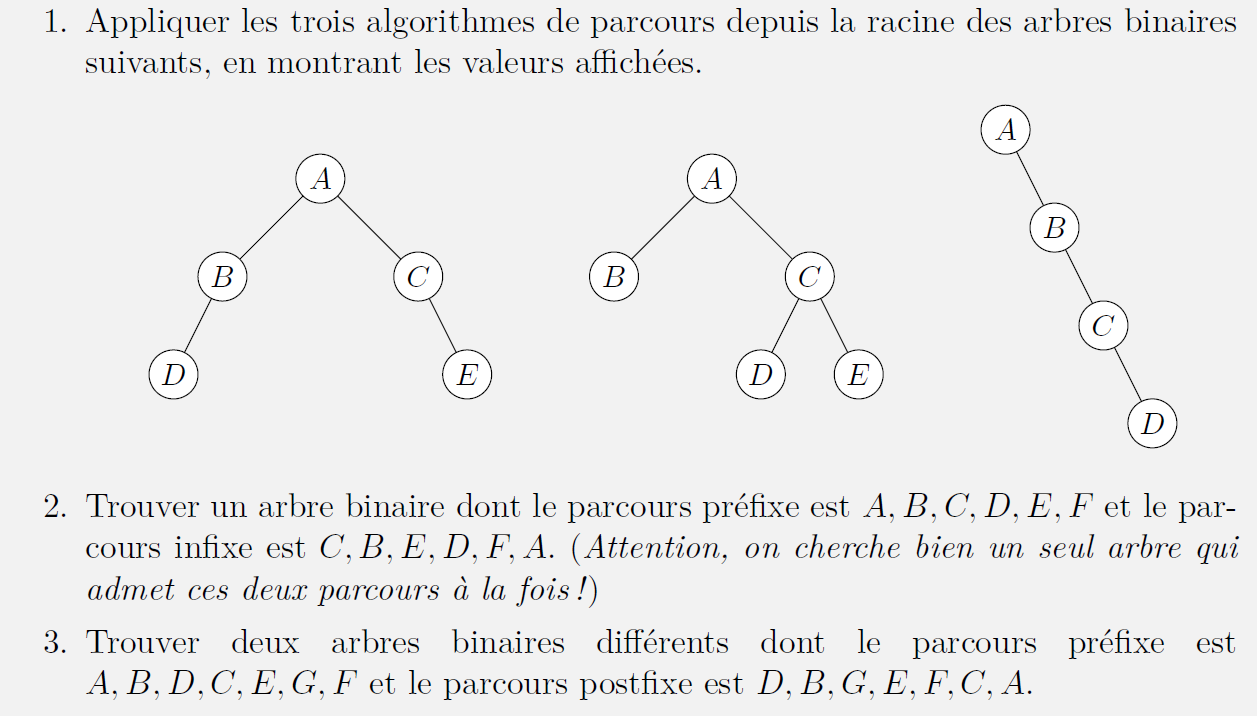

1)   
Parcours préfixe:    
  
Arbre 1 : A -> B -> D -> C -> E  
Arbre 2 : A -> B -> C -> D -> E  
Arbre 3 : A -> B -> C -> D
  
  
Parcours Postfixe:  
  
Arbre 1 : D -> B -> E -> C -> A  
Arbre 2 : B -> D -> E -> C -> A  
Arbre 3 : D -> C -> B -> A  
  

Parcours Infixe:  
  
Arbre 1 : D -> B -> A -> C -> E  
Arbre 2 : B -> A -> D -> C -> E  
Arbre 3 : A -> B -> C -> D  
  
  
2)  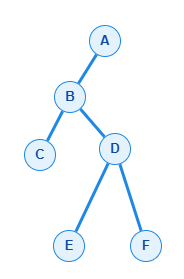  
  
3)  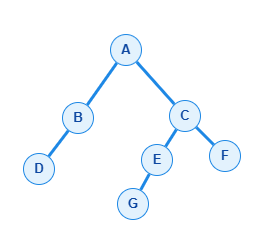